IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

LOAD DATASET

In [3]:
df = pd.read_csv("churn.csv")

In [20]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


Distribution Of Churn

In [12]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Visualize Churn Distribution

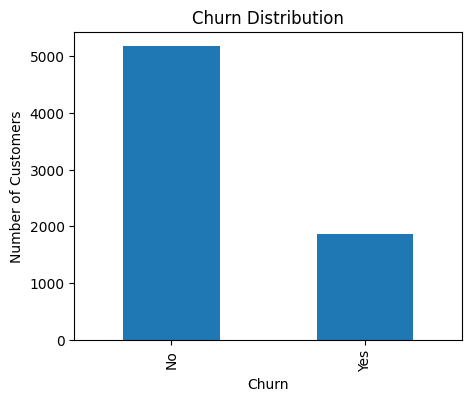

In [14]:
plt.figure(figsize=(5,4))
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

Gender Distribution

In [15]:
df["gender"].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

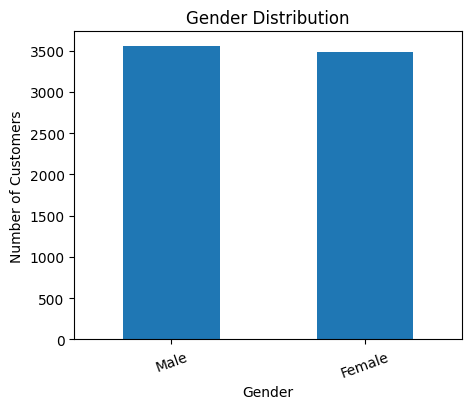

In [16]:
plt.figure(figsize=(5,4))
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

Contract Distribution

In [17]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

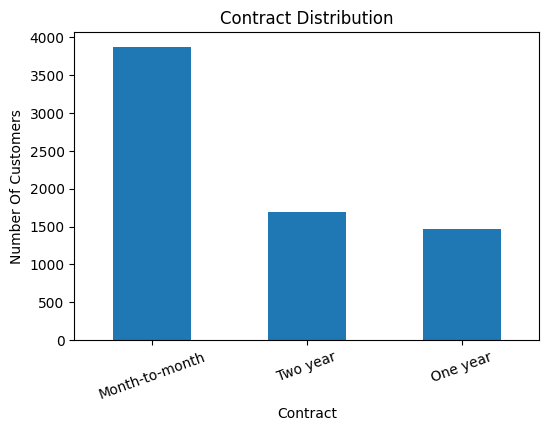

In [18]:
plt.figure(figsize=(6,4))
df["Contract"].value_counts().plot(kind="bar")
plt.title("Contract Distribution")
plt.xlabel("Contract")
plt.ylabel("Number Of Customers")
plt.xticks(rotation=20)
plt.show()

Internet Service Distribution

In [19]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

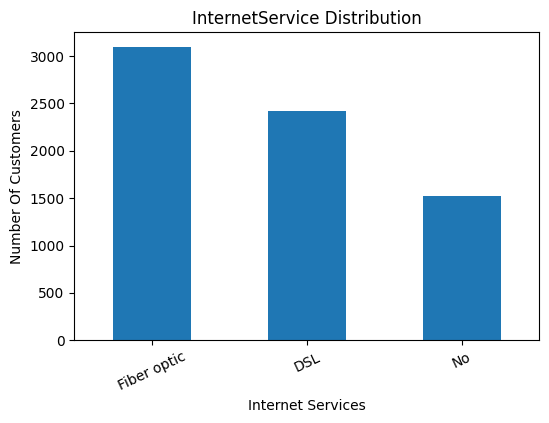

In [20]:
plt.figure(figsize=(6,4))
df["InternetService"].value_counts().plot(kind="bar")
plt.title("InternetService Distribution")
plt.xlabel("Internet Services")
plt.ylabel("Number Of Customers")
plt.xticks(rotation=25)
plt.show()

Payment Method Distribution

In [21]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

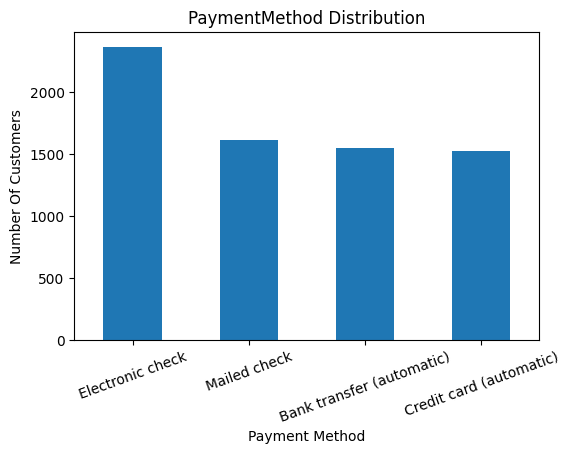

In [22]:
plt.figure(figsize=(6,4))
df["PaymentMethod"].value_counts().plot(kind="bar")
plt.title("PaymentMethod Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number Of Customers")
plt.xticks(rotation=20)
plt.show()

Distribution Of Monthly Charges

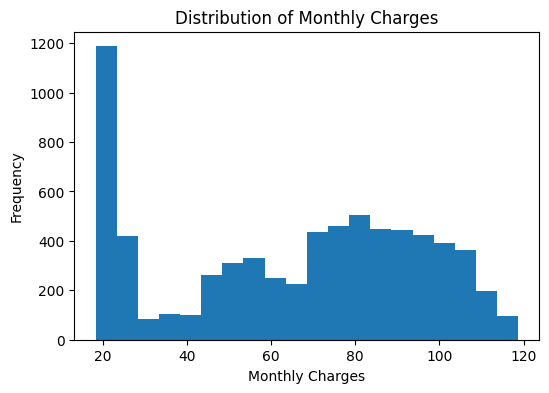

In [23]:
plt.figure(figsize=(6,4))
plt.hist(df["MonthlyCharges"],bins=20)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

Distribution Of Tenure

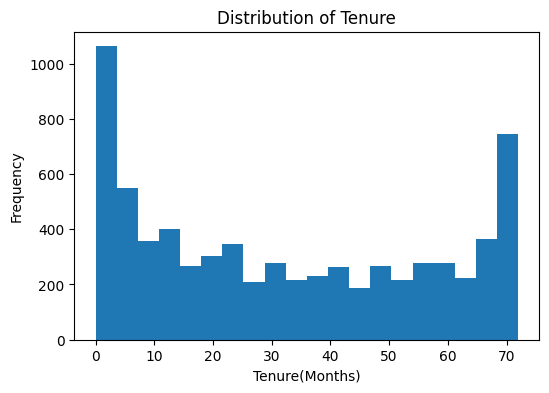

In [24]:
plt.figure(figsize=(6,4))
plt.hist(df["tenure"],bins=20)
plt.title("Distribution of Tenure")
plt.xlabel("Tenure(Months)")
plt.ylabel("Frequency")
plt.show()

Monthly Charges by Churn

<Figure size 600x400 with 0 Axes>

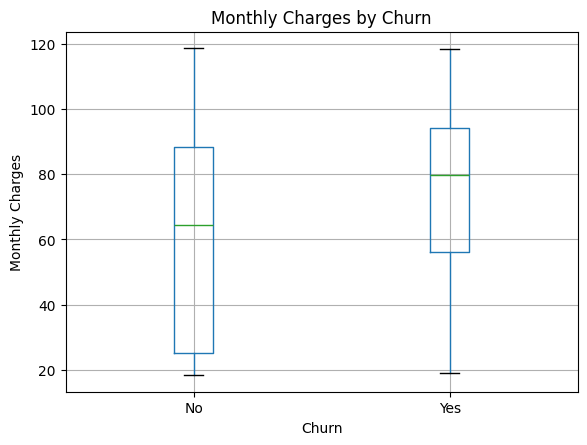

In [25]:
plt.figure(figsize=(6,4))
df.boxplot(column="MonthlyCharges", by="Churn")
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

Tenure by Churn

<Figure size 600x400 with 0 Axes>

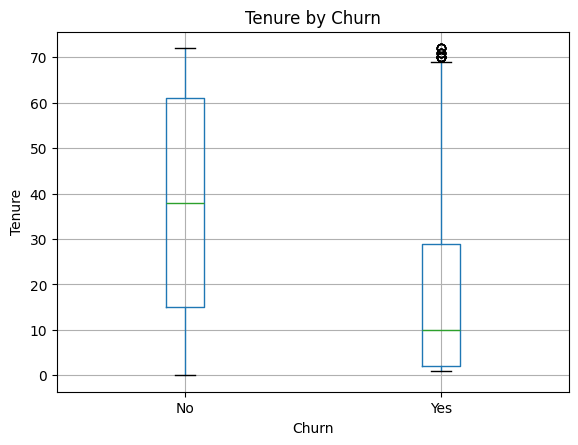

In [26]:
plt.figure(figsize=(6,4))
df.boxplot(column="tenure", by="Churn")
plt.title("Tenure by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

Bivariate EDA

In [27]:
# contract vs churn

pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [28]:
# contract vs churn (%)

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


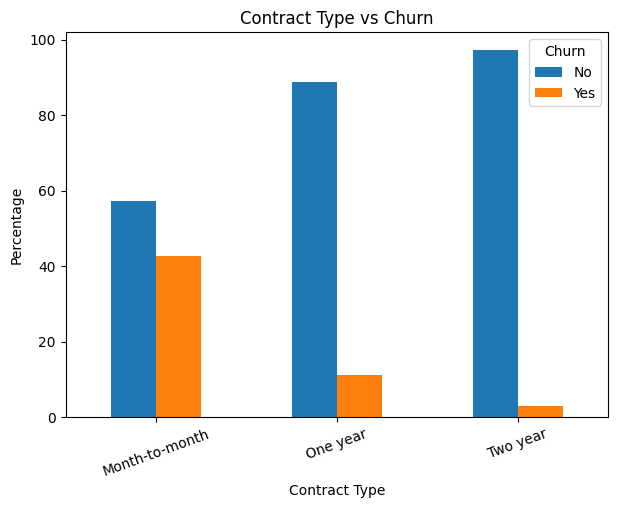

In [29]:
# visualize contract vs churn

contract_churn.plot(kind="bar",figsize=(7,5))

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.xticks(rotation=20)
plt.show()

In [30]:
# Internet Service vs Churn

pd.crosstab(df["InternetService"],df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [31]:
# Internet Service vs Churn (%)

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


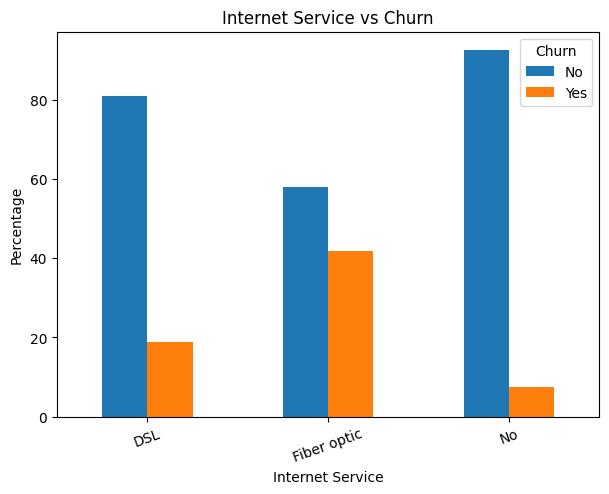

In [32]:
# Visualize Internet Srevice vs Churn

internet_churn.plot(kind="bar", figsize=(7,5))

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.xticks(rotation=20)
plt.show()

In [33]:
# Payment Method vs Churn

pd.crosstab(df["PaymentMethod"], df["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [34]:
# Payment Method vs Churn (%)

payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


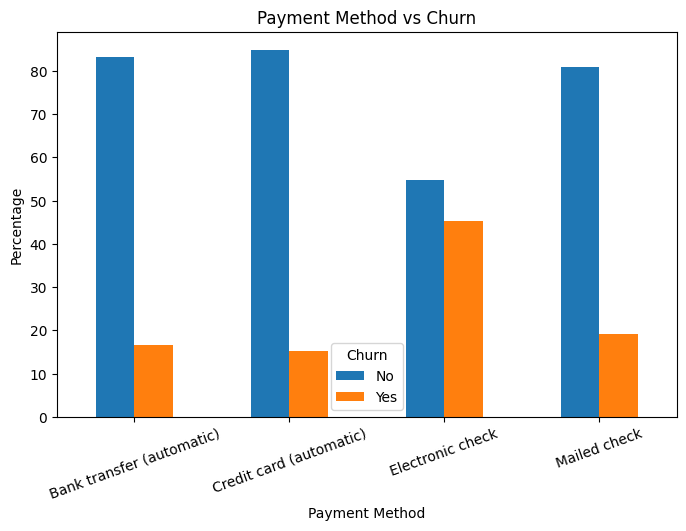

In [35]:
# Visualize Payment Method vs Churn

payment_churn.plot(kind="bar", figsize=(8,5))

plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.xticks(rotation=20)
plt.show()